# Weights

This notebook shows how to use the `weights` argument and the `scale_weights` flag in IXPLORE.

- **`weights`** — per-(user, item) numbers that multiply each answer's contribution to the log-likelihood. A weight of `c` is equivalent to having answered the item `c` times; a weight of `0` is equivalent to not answering at all.
- **`scale_weights`** — a constructor flag. When `True`, each user's effective weight row is rescaled so it sums to `K` (the number of items). This equalizes the *effective* sample size across users with very different response counts.

`weights` can be passed in two places:

| Where | Type | Effect |
|---|---|---|
| `IXPLORE(reactions, weights=...)` | `(N, K)` DataFrame matching `reactions` | applied during `fit_posteriors` / `iterate` (training) |
| `model.embed(answers, weights=...)`, `compute_posteriors`, `predict_answers`, `impute_answers` | `Series` (single user) or `DataFrame` (batch) | applied at inference time for new or held-out users |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ixplore import IXPLORE
from ixplore.visualization import plot_embedding, plot_posterior


## Load a pretrained model

We reuse the embedding and item parameters trained in `demo.ipynb` so we can focus purely on inference behaviour.


In [2]:
users = pd.read_csv('../data/synthetic_users.csv', index_col=0)
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)

xplore = IXPLORE(reactions,
                 pretrained_embedding=embedding,
                 pretrained_models=models)


ixplore - INFO - 2026-04-30 09:58:41 - IXPLORE initialized: 250 users × 70 items (0 missing, 0.00%), grid 100×100, prior var=1.0.
ixplore - INFO - 2026-04-30 09:58:41 - Initial — mae: 0.0614, accuracy: 0.9854, spread: 0.6521, boundary: 0.0000


## Inference-time weights: emphasizing one answer

We pick two questions whose decision boundaries point in roughly opposite directions and have a new user answer both with `1`. Each answer pulls the embedding to the opposite half-plane, so the user is under genuine conflicting evidence.


In [3]:
betas = xplore.get_parameters()[['beta1', 'beta2']]
directions = betas.values / np.linalg.norm(betas.values, axis=1, keepdims=True)
sims = directions @ directions.T
np.fill_diagonal(sims, 0)
ia, ib = np.unravel_index(np.argmin(sims), sims.shape)
qa, qb = xplore.items[ia], xplore.items[ib]
print(f'Conflicting pair: {qa} vs {qb}  (cos sim = {sims[ia, ib]:.3f})')

answers = pd.Series({qa: 1.0, qb: 1.0}, name='new_user')


Conflicting pair: Q55 vs Q61  (cos sim = -1.000)


Sweeping `w(qa)` while keeping `w(qb) = 1` changes how much each answer contributes to the log-likelihood. We sweep `log(w(qa))` from `-10` to `+10` in 5 steps, plotting the posterior heatmap and the point estimate (white circle) at each setting.

At low `log(w)`, qa is effectively absent and the posterior is the qb-only posterior. As `log(w)` grows, the posterior shifts toward the qa-favoured side. At the largest values the posterior contracts to a narrow band along the qa boundary.


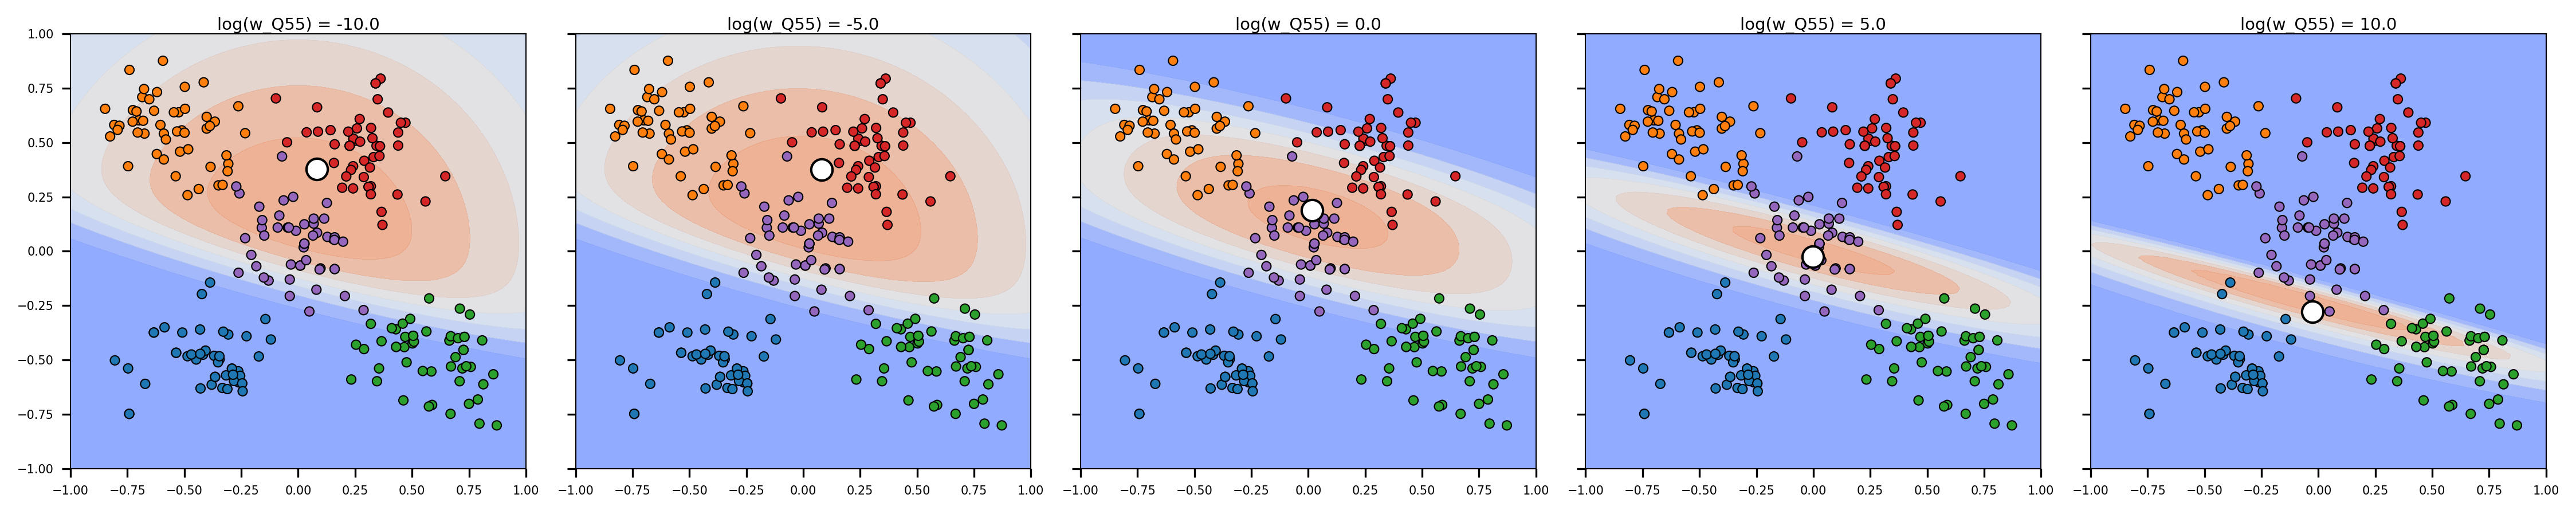

In [17]:
weight_values = np.exp(np.linspace(-10, 10, 5))

fig, axes = plt.subplots(1, len(weight_values), figsize=(3 * len(weight_values), 3),
                         sharex=True, sharey=True)
for ax, w in zip(axes, weight_values):
    weights = pd.Series({qa: w, qb: 1.0})
    plot_embedding(xplore.get_embedding(), colors=users.color, s=15, ax=ax)
    plot_posterior(xplore, answers, weights=weights, ax=ax, add_bar=False)
    pos = xplore.embed(answers, weights=weights)
    ax.scatter(*pos, color='white', edgecolors='black', s=80, zorder=10)
    ax.set_title(f'log(w_{qa}) = {np.log(w):.1f}')
fig.tight_layout()


## The `scale_weights` flag

`scale_weights=True` row-normalizes the effective weight vector `W = mask * weights` so its row sum equals $K$ (the number of items in the questionnaire). For a 2-answer user with weights `(w, 1)`, the rescaled effective weights are `(wK/(w+1), K/(w+1))`.

We re-run the same sweep with the flag on.

At low `log(w)`, the posterior matches the plain sweep — it is the qb-only posterior. At high `log(w)`, instead of contracting to a narrow band, the posterior settles on a broad heatmap on the qa-favoured side. Across the sweep the effective weights stay bounded, so the posterior's spread is roughly preserved.


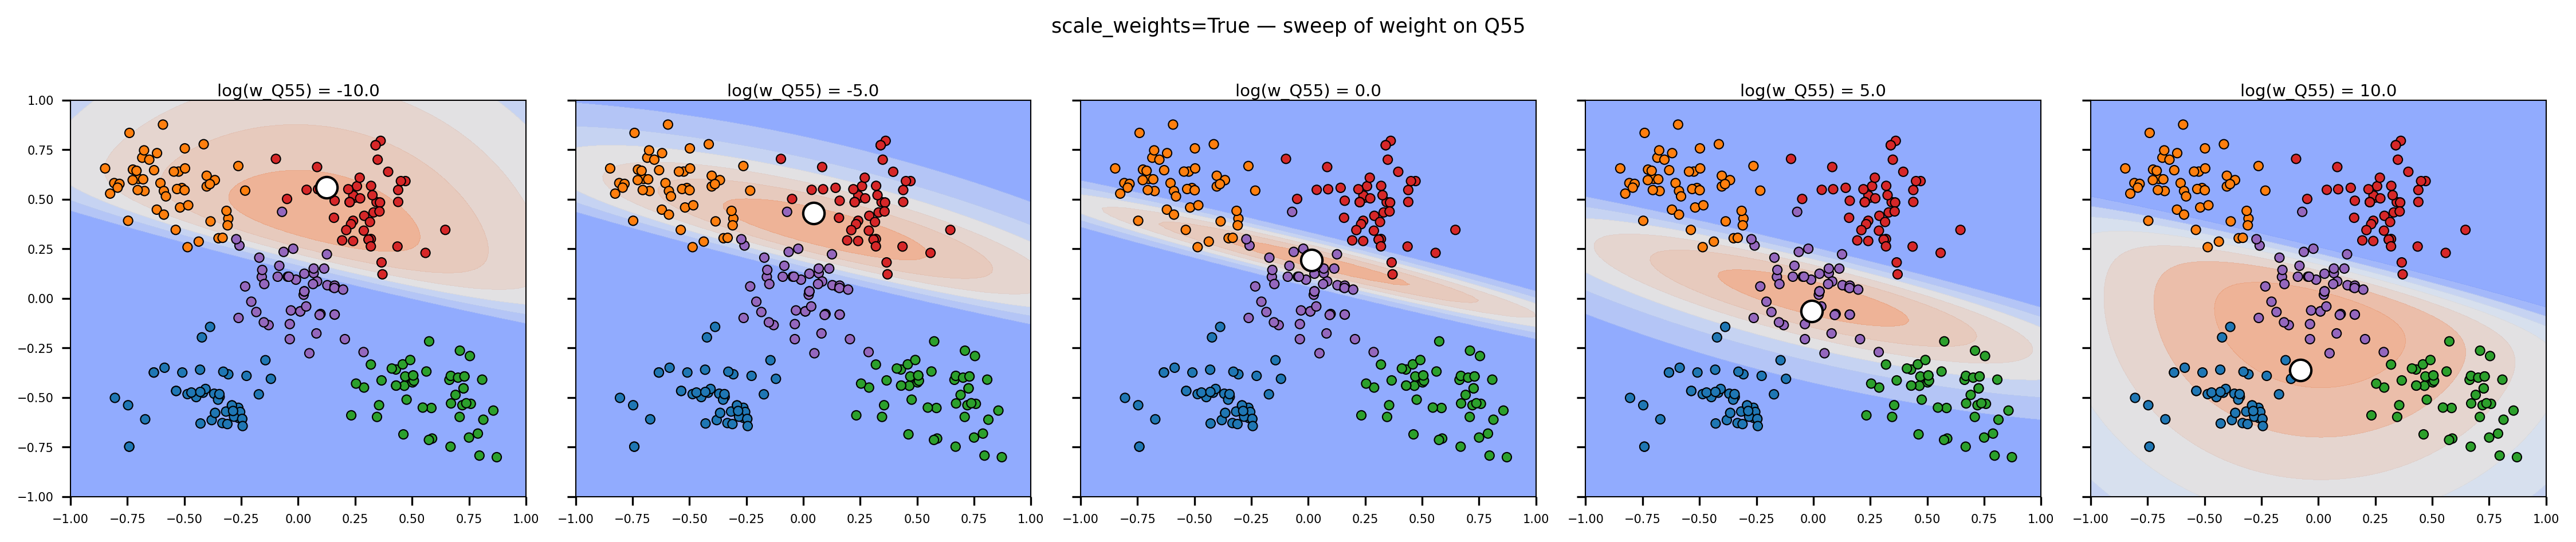

In [16]:
xplore.scale_weights = True
weight_values = np.exp(np.linspace(-10, 10, 5))

fig, axes = plt.subplots(1, len(weight_values), figsize=(3 * len(weight_values), 3),
                         sharex=True, sharey=True)
for ax, w in zip(axes, weight_values):
    weights = pd.Series({qa: w, qb: 1.0})
    plot_embedding(xplore.get_embedding(), colors=users.color, s=15, ax=ax)
    plot_posterior(xplore, answers, weights=weights, ax=ax, add_bar=False)
    pos = xplore.embed(answers, weights=weights)
    ax.scatter(*pos, color='white', edgecolors='black', s=80, zorder=10)
    ax.set_title(f'log(w_{qa}) = {np.log(w):.1f}')
fig.suptitle(f'scale_weights=True — sweep of weight on {qa}', y=1.02)
fig.tight_layout()
xplore.scale_weights = False  # restore default


## Effective-weight reference

The effective weight row `W = mask * weights` is what feeds the log-likelihood. The flag's only job is whether to row-normalize that row to sum to $K$.

| input weights (for a 2-answer user) | `scale_weights=False` | `scale_weights=True` |
|---|---|---|
| `None` | `(1, 1)` | `(K/2, K/2)` |
| `(1, 1)` | `(1, 1)` | `(K/2, K/2)` |
| `(10, 10)` | `(10, 10)` | `(K/2, K/2)` &mdash; same as `(1, 1)` |
| `(5, 1)` | `(5, 1)` | `(5K/6, K/6)` |
| `(1, 0)` | `(1, 0)` | `(K, 0)` &mdash; maxed out on qa |
| `pd.Series({qa: 5})` (missing keys default to 1) | `(5, 1)` | `(5K/6, K/6)` |
| negative weight `(-1, 1)` | raises `AssertionError` | raises `AssertionError` |
| `NaN` weight | silently filled with `1.0` | silently filled with `1.0` |

So `scale_weights=True` makes weights **scale-invariant** — only ratios matter, and the row sum is always $K$. With `scale_weights=False`, weights act as raw vote-count multipliers and large values can overpower the prior.
